# TP - Classification de pièces de monnaie avec AlexNet
**Master 1 Informatique VMI - IFLBE055**  
Réseaux de neurones pour la vision par ordinateur

In [4]:
import os

# Voir ce qu'il y a dans le répertoire courant
print("Répertoire courant :", os.getcwd())
print("\nContenu :")
for item in os.listdir("."):
    print(" ", item)




Répertoire courant : c:\Users\aniso\OneDrive\Bureau\Projet Massiz

Contenu :
  AlexNet_Coin_Classification_T2000.ipynb
  alexnet_pretrained_best.pth
  coins
  eda_analysis.png
  sample_images.png
  tp_coin_classification_alexnet (1).ipynb
  tp_coin_classification_alexnet.ipynb
  training_curves.png
  venv310


## 1. Imports & Configuration

In [5]:
import os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from tqdm.notebook import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device utilisé : {DEVICE}")

Device utilisé : cuda


## 2. Chargement des données

In [6]:
# Adapter le chemin si besoin
DATA_DIR  = "coins"
TRAIN_IMG = os.path.join(DATA_DIR, "train")
TEST_IMG  = os.path.join(DATA_DIR, "test")

train_df = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))
test_df  = pd.read_csv(os.path.join(DATA_DIR, "test.csv"))

print(f"Train : {train_df.shape}  |  Test : {test_df.shape}")
print(f"Nombre de classes : {train_df['Class'].nunique()}")
train_df.head()

Train : (10368, 2)  |  Test : (1282, 1)
Nombre de classes : 315


,Id,Class
0,1,"1 Cent,Australian dollar,australia"
1,2,"1 Cent,Australian dollar,australia"
2,3,"1 Cent,Australian dollar,australia"
3,4,"1 Cent,Australian dollar,australia"
4,5,"1 Cent,Australian dollar,australia"


## 3. Exploration des données (EDA)

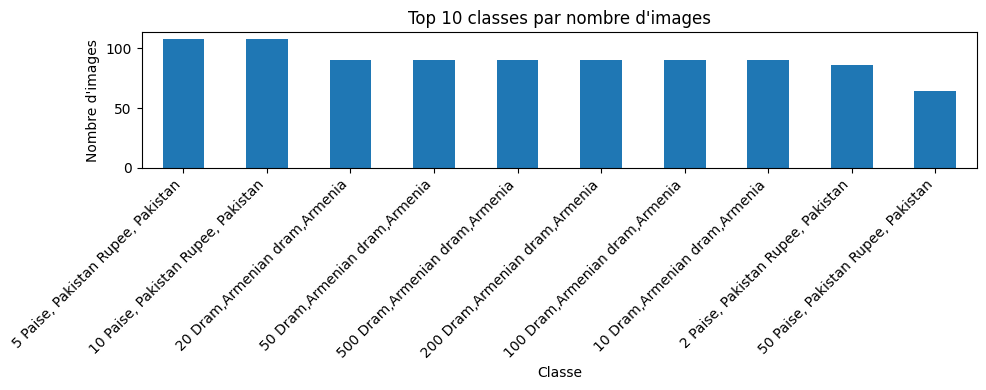

Classe la plus fréquente  : 108 images
Classe la moins fréquente : 13 images


In [7]:
class_counts = train_df['Class'].value_counts()

plt.figure(figsize=(10, 4))
class_counts.head(10).plot(kind='bar')
plt.title("Top 10 classes par nombre d'images")
plt.xlabel("Classe")
plt.ylabel("Nombre d'images")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f"Classe la plus fréquente  : {class_counts.max()} images")
print(f"Classe la moins fréquente : {class_counts.min()} images")

## 4. Encodage des classes & Split Train/Val

In [8]:
le = LabelEncoder()
train_df["label"] = le.fit_transform(train_df["Class"])
NUM_CLASSES = len(le.classes_)
print(f"Nombre de classes : {NUM_CLASSES}")

train_data, val_data = train_test_split(
    train_df, test_size=0.15, random_state=SEED, stratify=train_df["label"]
)
print(f"Train : {len(train_data)}  |  Val : {len(val_data)}")

Nombre de classes : 315
Train : 8812  |  Val : 1556


## 5. Dataset & Transformations

In [9]:
def skip_none_collate(batch):
    batch = [item for item in batch if item is not None]
    if len(batch) == 0:
        return None
    return torch.utils.data.dataloader.default_collate(batch)


class CoinDataset(Dataset):
    def __init__(self, df, img_dir, transform=None, is_test=False):
        self.df        = df.reset_index(drop=True)
        self.img_dir   = img_dir
        self.transform = transform
        self.is_test   = is_test

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_id = self.df.loc[idx, "Id"]
        path = None
        for ext in [".jpg", ".png", ".jpeg", ".webp"]:  # extension vide retirée
            candidate = os.path.join(self.img_dir, f"{img_id}{ext}")
            if os.path.exists(candidate):
                path = candidate
                break

        if path is None:
            return None  # image introuvable ou sans extension -> skip

        try:
            image = Image.open(path).convert("RGB")
        except Exception:
            return None  # image corrompue -> skip

        if self.transform:
            image = self.transform(image)
        if self.is_test:
            return image, img_id
        return image, self.df.loc[idx, "label"]


MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

BATCH_SIZE  = 64
NUM_WORKERS = 0  # mettre 0 si erreur

train_dataset = CoinDataset(train_data, TRAIN_IMG, transform=train_transform)
val_dataset   = CoinDataset(val_data,   TRAIN_IMG, transform=val_transform)
test_dataset  = CoinDataset(test_df,    TEST_IMG,  transform=val_transform, is_test=True)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, collate_fn=skip_none_collate)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, collate_fn=skip_none_collate)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, collate_fn=skip_none_collate)

print(f"Batches — train: {len(train_loader)} | val: {len(val_loader)} | test: {len(test_loader)}")

Batches — train: 138 | val: 25 | test: 21


## 6. Modèle AlexNet (Fine-Tuning)

In [10]:
def build_alexnet(num_classes):
    model = models.alexnet(weights=models.AlexNet_Weights.IMAGENET1K_V1)
    in_features = model.classifier[6].in_features  # 4096
    model.classifier[6] = nn.Linear(in_features, num_classes)
    return model

model = build_alexnet(NUM_CLASSES).to(DEVICE)

print("Classifieur AlexNet :")
print(model.classifier)
total_params    = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nParamètres totaux      : {total_params:,}")
print(f"Paramètres entraînables : {trainable_params:,}")

Classifieur AlexNet :
Sequential(
  (0): Dropout(p=0.5, inplace=False)
  (1): Linear(in_features=9216, out_features=4096, bias=True)
  (2): ReLU(inplace=True)
  (3): Dropout(p=0.5, inplace=False)
  (4): Linear(in_features=4096, out_features=4096, bias=True)
  (5): ReLU(inplace=True)
  (6): Linear(in_features=4096, out_features=315, bias=True)
)

Paramètres totaux      : 58,294,395
Paramètres entraînables : 58,294,395


## 7. Entraînement

In [11]:
EPOCHS          = 8
LR              = 1e-4
SCHEDULER_STEP  = 7
best_model_path = "best_alexnet_coins.pth"

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=SCHEDULER_STEP, gamma=0.5)

best_val_acc = 0.0
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}


def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for images, labels in tqdm(loader, leave=False):
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            if train:
                optimizer.zero_grad()
            outputs = model(images)
            loss    = criterion(outputs, labels)
            if train:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * images.size(0)
            correct    += (outputs.argmax(1) == labels).sum().item()
            total      += images.size(0)
    return total_loss / total, correct / total


for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = run_epoch(train_loader, train=True)
    val_loss,   val_acc   = run_epoch(val_loader,   train=False)
    scheduler.step()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    saved = ""
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)
        saved = "  ✓ sauvegardé"

    print(f"Epoch {epoch:02d}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}{saved}")

print(f"\nMeilleure val accuracy : {best_val_acc:.4f}")

  0%|          | 0/138 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

Epoch 01/8 | Train Loss: 4.0173 Acc: 0.2376 | Val Loss: 2.4160 Acc: 0.4685  ✓ sauvegardé


  0%|          | 0/138 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

...

  0%|          | 0/25 [00:00<?, ?it/s]

Epoch 07/8 | Train Loss: 0.2999 Acc: 0.9115 | Val Loss: 1.2644 Acc: 0.7378  ✓ sauvegardé


  0%|          | 0/138 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

Epoch 08/8 | Train Loss: 0.1715 Acc: 0.9495 | Val Loss: 1.1035 Acc: 0.7648  ✓ sauvegardé

Meilleure val accuracy : 0.7648


## 8. Courbes d'apprentissage

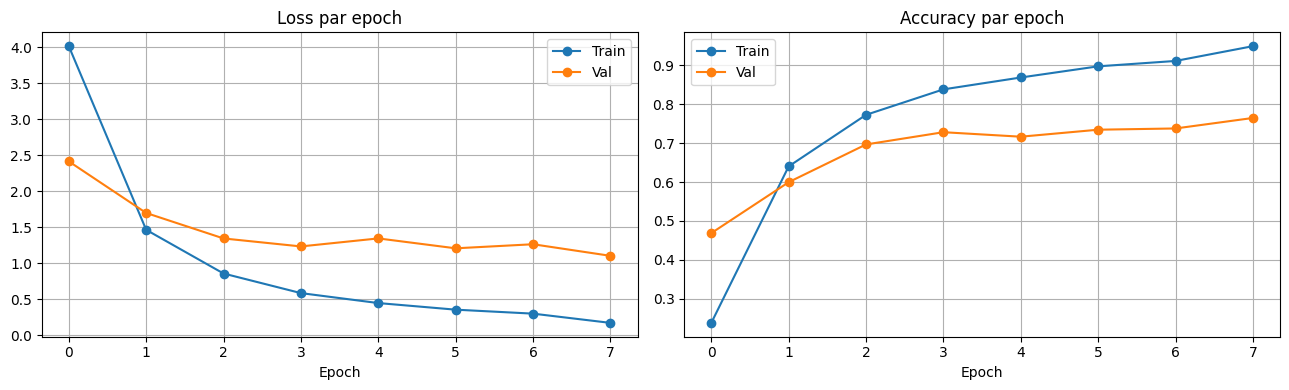

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history["train_loss"], label="Train", marker='o')
axes[0].plot(history["val_loss"],   label="Val",   marker='o')
axes[0].set_title("Loss par epoch")
axes[0].set_xlabel("Epoch")
axes[0].legend(); axes[0].grid(True)

axes[1].plot(history["train_acc"], label="Train", marker='o')
axes[1].plot(history["val_acc"],   label="Val",   marker='o')
axes[1].set_title("Accuracy par epoch")
axes[1].set_xlabel("Epoch")
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()

## 9. Évaluation finale (meilleur modèle)

In [13]:
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
_, final_val_acc = run_epoch(val_loader, train=False)
print(f"Accuracy finale sur la validation : {final_val_acc:.4f}  ({final_val_acc*100:.2f}%)")

C:\Users\aniso\AppData\Local\Temp\ipykernel_19912\4077977048.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_model_path, map_locati

  0%|          | 0/25 [00:00<?, ?it/s]

Accuracy finale sur la validation : 0.7648  (76.48%)


## 10. Génération du fichier submission.csv

In [14]:
model.eval()
ids_list, preds_list = [], []

with torch.no_grad():
    for images, img_ids in tqdm(test_loader, desc="Prédiction test"):
        images  = images.to(DEVICE)
        outputs = model(images)
        preds   = outputs.argmax(dim=1).cpu().numpy()
        ids_list.extend(img_ids if isinstance(img_ids, list) else img_ids.numpy().tolist())
        preds_list.extend(preds)

class_names   = le.inverse_transform(preds_list)
submission_df = pd.DataFrame({"Id": ids_list, "Class": class_names})
submission_df.to_csv("submission.csv", index=False)

print("✓ submission.csv généré !")
print(f"Lignes : {len(submission_df)}")
submission_df.head(10)

Prédiction test:   0%|          | 0/21 [00:00<?, ?it/s]

✓ submission.csv généré !
Lignes : 1282


,Id,Class
0,33,"1 Cent,Australian dollar,australia"
1,34,"1 Cent,Australian dollar,australia"
2,35,"1 Cent,Australian dollar,australia"
3,36,"1 Cent,Australian dollar,australia"
4,69,"2 Cents,Euro,luxembourg"
5,70,"2 Cents,Australian dollar,australia"
6,71,"2 Cents,Australian dollar,australia"
7,72,"2 Cents,Australian dollar,australia"
8,103,"5 Cents,Australian dollar,australia"
9,104,"5 Cents,Australian dollar,australia"
